In [1]:
## Imports

import pandas as pd
import numpy as np
import cv2, os, glob, random
import matplotlib.pyplot as plt


In [2]:
## Data imports

usrFolder = os.path.expanduser('~')
mainFolder = os.path.join(usrFolder,'Desktop','archive')
foldsPath = os.path.join(mainFolder,'Folds.csv')
dataPath = os.path.join(mainFolder,'BreaKHis_v1')


In [ ]:
# Dataframe Assigning

folds = pd.read_csv(foldsPath)


# add filename for each sample in new column
folds["path"] = dataPath + os.sep + folds["filename"]

# extract information from each sample filename
meta = folds["filename"].str.extract(
    r"(SOB_(?P<cls>[BM])_(?P<subtype>[A-Z]+)-(?P<patient>\d+-[0-9A-Z]+)-\d+-\d+\.png$)"
)
folds = folds.join(meta)

# turn M and B into 1 and 0, respectively
folds["diagnosis"] = (folds["cls"] == "M").astype(int)

# Dataset image resizing

from PIL import Image
import os

resized = "Resized Images"

for tempPath in folds["filename"].unique():
    originalImg = os.path.join(dataPath, tempPath)
    location = os.path.join(resized, tempPath)
    os.makedirs(os.path.dirname(location), exist_ok = True)
    with Image.open(originalImg) as img:
        img.convert('RGB').resize((224,224)).save(location,'PNG')

folds['path'] = resized + os.sep + folds['filename']  

splits = {}

# segment data into folds, then into test/train. Assign this data to splits df
for k, fold_df in folds.groupby("fold"):
    temp = {}
    for grp, g in fold_df.groupby("grp"):
        temp[grp] = g
    splits[k] = temp


# Assign new test/training dataframes for each fold

test_df_1 = splits[1]["test"]
test_df_2 = splits[2]["test"]
test_df_3 = splits[3]["test"]
test_df_4 = splits[4]["test"]
test_df_5 = splits[5]["test"]

train_df_1 = splits[1]["train"]
train_df_2 = splits[2]["train"]
train_df_3 = splits[3]["train"]
train_df_4 = splits[4]["train"]
train_df_5 = splits[5]["train"]

# Reset Index of Train and Test Fold = 3
train_df_3 = train_df_3.reset_index()
train_df_3.drop(columns=['index'], inplace=True)

test_df_3 = train_df_3.reset_index()
test_df_3.drop(columns=['index'], inplace=True)

In [4]:
train_df_3

,fold,mag,grp,filename,path,0,cls,subtype,patient,diagnosis
0,3,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_B_A-14-22549AB-100-001.png,B,A,14-22549AB,0
1,3,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_B_A-14-22549AB-100-002.png,B,A,14-22549AB,0
2,3,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_B_A-14-22549AB-100-003.png,B,A,14-22549AB,0
3,3,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_B_A-14-22549AB-100-004.png,B,A,14-22549AB,0
4,3,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_B_A-14-22549AB-100-005.png,B,A,14-22549AB,0
...,...,...,...,...,...,...,...,...,...,...
5327,3,400,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_PC-14-9146-400-020.png,M,PC,14-9146,1
5328,3,400,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_PC-14-9146-400-021.png,M,PC,14-9146,1
5329,3,400,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_PC-14-9146-400-022.png,M,PC,14-9146,1
5330,3,400,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_PC-14-9146-400-023.png,M,PC,14-9146,1


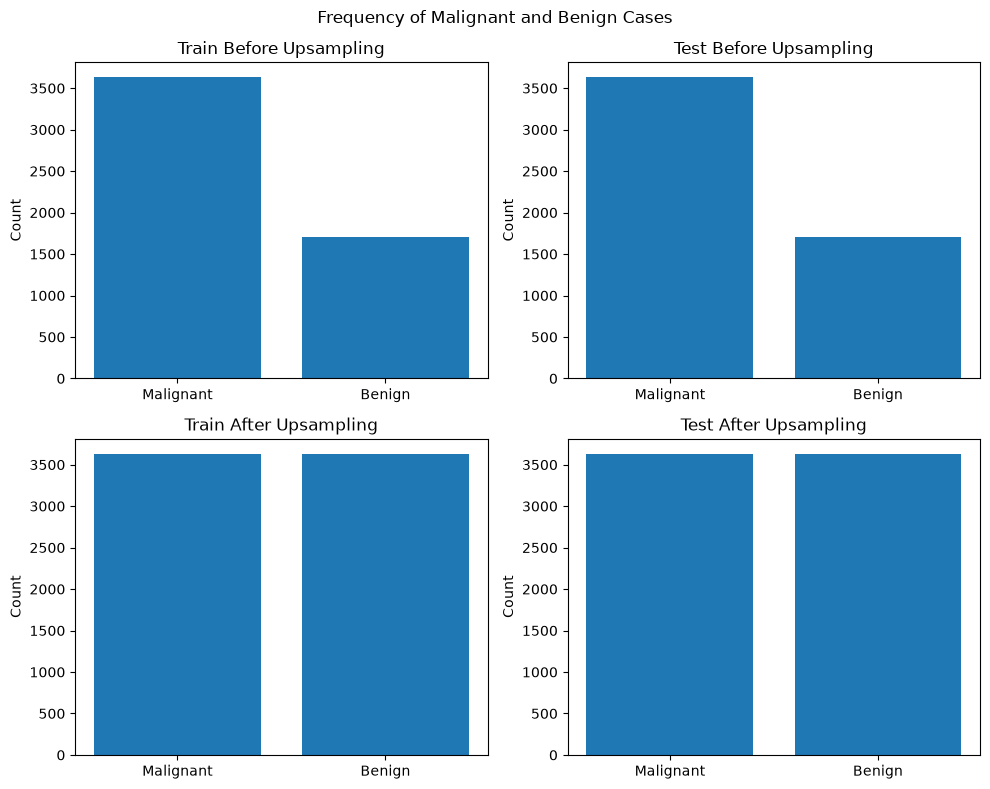

In [5]:
# Random Upsampling
def upsample(df: pd.DataFrame, label_col: str = 'diagnosis', seed: int = 42) -> pd.DataFrame:
    counts = df[label_col].value_counts()
    minority_label = counts.idxmin()

    minority = df[df[label_col] == minority_label]
    diff = counts.max() - counts.min()

    # Sample minority rows with replacement, all in one call
    extra = minority.sample(n=diff, replace=True, random_state=seed)

    # Return original data + extra samples, shuffled
    return pd.concat([df, extra]).sample(frac=1, random_state=seed).reset_index(drop=True)

train_df_3_up = upsample(train_df_3)
test_df_3_up = upsample(test_df_3)

# Examine Dataset Balance
def plot_balance(ax, df, title):
    counts = df['diagnosis'].value_counts()
    ax.bar(['Malignant', 'Benign'], [counts.get(1, 0), counts.get(0, 0)])
    ax.set_title(title)
    ax.set_ylabel("Count")

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

plot_balance(ax[0, 0], train_df_3,    "Train Before Upsampling")
plot_balance(ax[0, 1], test_df_3,     "Test Before Upsampling")
plot_balance(ax[1, 0], train_df_3_up, "Train After Upsampling")
plot_balance(ax[1, 1], test_df_3_up,  "Test After Upsampling")

fig.suptitle("Frequency of Malignant and Benign Cases")
fig.tight_layout()
plt.show()

In [6]:
train_df_3_up

,fold,mag,grp,filename,path,0,cls,subtype,patient,diagnosis
0,3,200,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_LC-14-15570-200-003.png,M,LC,14-15570,1
1,3,200,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_DC-14-20636-200-018.png,M,DC,14-20636,1
2,3,40,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_B_PT-14-21998AB-40-033.png,B,PT,14-21998AB,0
3,3,40,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_DC-14-14926-40-005.png,M,DC,14-14926,1
4,3,100,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_DC-14-17901-100-014.png,M,DC,14-17901,1
...,...,...,...,...,...,...,...,...,...,...
7255,3,200,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_DC-14-4372-200-012.png,M,DC,14-4372,1
7256,3,40,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_PC-14-15704-40-015.png,M,PC,14-15704,1
7257,3,400,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_PC-14-15704-400-020.png,M,PC,14-15704,1
7258,3,200,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_B_A-14-22549G-200-012.png,B,A,14-22549G,0


In [7]:
test_df_3_up

,fold,mag,grp,filename,path,0,cls,subtype,patient,diagnosis
0,3,200,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_LC-14-15570-200-003.png,M,LC,14-15570,1
1,3,200,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_DC-14-20636-200-018.png,M,DC,14-20636,1
2,3,40,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_B_PT-14-21998AB-40-033.png,B,PT,14-21998AB,0
3,3,40,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_DC-14-14926-40-005.png,M,DC,14-14926,1
4,3,100,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_DC-14-17901-100-014.png,M,DC,14-17901,1
...,...,...,...,...,...,...,...,...,...,...
7255,3,200,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_DC-14-4372-200-012.png,M,DC,14-4372,1
7256,3,40,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_PC-14-15704-40-015.png,M,PC,14-15704,1
7257,3,400,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_PC-14-15704-400-020.png,M,PC,14-15704,1
7258,3,200,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_B_A-14-22549G-200-012.png,B,A,14-22549G,0


In [8]:
def random_augment_cv2(image):
    """Applies random flips, 90-deg rotations, arbitrary angles, and brightness/contrast."""
    # 1. Random Horizontal Flip
    if random.random() > 0.5:
        image = cv2.flip(image, 1)
        
    # 2. Random Vertical Flip
    if random.random() > 0.5:
        image = cv2.flip(image, 0)
        
    # 3. Random Rotation (0, 90, 180, 270 degrees)
    rot_k = random.choice([0, 1, 2, 3])
    if rot_k > 0:
        image = np.rot90(image, k=rot_k)

    # 4. Random Brightness & Contrast Adjustment
    if random.random() > 0.5:
        alpha = random.uniform(0.8, 1.2)  # Contrast factor
        beta = random.randint(-30, 30)     # Brightness offset
        image = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

    return image


def augment(
    df, 
    output_dir=r"../data/augmented_images", 
    num_augmented_copies=1,
    path_col='path'
):
    os.makedirs(output_dir, exist_ok=True)
    new_rows = []

    print(f"Processing {len(df)} images from DataFrame...")

    for idx, row in df.iterrows():
        img_path = row[path_col]
        
        if not os.path.exists(img_path):
            print(f"Warning: File not found at {img_path}. Skipping.")
            continue

        # Load image (OpenCV loads BGR)
        image = cv2.imread(img_path)
        if image is None:
            continue

        orig_filename = os.path.basename(img_path)
        name, ext = os.path.splitext(orig_filename)

        # Generate augmented copies
        for i in range(num_augmented_copies):
            # Apply random transforms
            augmented = random_augment_cv2(image)

            new_filename = f"{name}_aug_{i}{ext}"
            new_path = os.path.join(output_dir, new_filename)

            # Save newly augmented image to disk
            cv2.imwrite(new_path, augmented)

            # Duplicate metadata row and update path
            new_row = row.copy()
            new_row[path_col] = new_path
            
            if 'filename' in df.columns:
                new_row['filename'] = new_filename

            new_rows.append(new_row)

    augmented_df = pd.DataFrame(new_rows)
    return(augmented_df)



In [9]:
train_df_3_aug = augment(df = train_df_3_up, output_dir=r"../data/augmented_images",
    num_augmented_copies=1,  # 1 creates one new image per original row (doubles dataset)
    path_col='path'
)

train_df_3_aug.head()

Processing 7260 images from DataFrame...


,fold,mag,grp,filename,path,0,cls,subtype,patient,diagnosis
0,3,200,train,SOB_M_LC-14-15570-200-003_aug_0.png,../data/augmented_images/SOB_M_LC-14-15570-200...,SOB_M_LC-14-15570-200-003.png,M,LC,14-15570,1
1,3,200,train,SOB_M_DC-14-20636-200-018_aug_0.png,../data/augmented_images/SOB_M_DC-14-20636-200...,SOB_M_DC-14-20636-200-018.png,M,DC,14-20636,1
2,3,40,train,SOB_B_PT-14-21998AB-40-033_aug_0.png,../data/augmented_images/SOB_B_PT-14-21998AB-4...,SOB_B_PT-14-21998AB-40-033.png,B,PT,14-21998AB,0
3,3,40,train,SOB_M_DC-14-14926-40-005_aug_0.png,../data/augmented_images/SOB_M_DC-14-14926-40-...,SOB_M_DC-14-14926-40-005.png,M,DC,14-14926,1
4,3,100,train,SOB_M_DC-14-17901-100-014_aug_0.png,../data/augmented_images/SOB_M_DC-14-17901-100...,SOB_M_DC-14-17901-100-014.png,M,DC,14-17901,1
